In [48]:
import os
import sys
sys.path.append('/home/royhirsch/conformal/')

from ml_collections import config_dict
import logging
import pandas as pd
import pickle
import torch
import torch.nn as nn

from conformal import get_conformal_module, get_percentile, clip_scores, calibrate_residual
from conformal_baselines import calc_baseline_mets
from data import get_dataloaders
from model import NN
from trainer import Trainer, get_optimizer, get_scheduler
from config import get_config_by_name
import utils as utils


In [49]:
config = get_config_by_name('tissuemnist')
config.conformal_module_name = 'aps'
config.num_epochs = 100
config.use_score_clipping = False 

utils.seed_everything(config.seed)

conformal_module = get_conformal_module(config.conformal_module_name)
dls, t = get_dataloaders(config, conformal_module)
train_dl = dls['train']
valid_dl = dls['valid']
test_dl = dls['test']
baseline_mets = calc_baseline_mets(train_dl, valid_dl, alpha=config.alpha, k_raps=config.k_raps)


  2%|▏         | 2/100 [00:01<01:31,  1.07it/s]


In [50]:
train_labels = train_dl.dataset.cls_labels.numpy()
train_probs = train_dl.dataset.cls_probs.numpy()

val_labels = test_dl.dataset.cls_labels.numpy()
val_probs = test_dl.dataset.cls_probs.numpy()


## APS

In [129]:
import numpy as np
alpha = 0.1


n = len(train_probs)
cal_pi = train_probs.argsort(1)[:, ::-1]
cal_srt = np.take_along_axis(train_probs, cal_pi, axis=1).cumsum(axis=1)
cal_scores = np.take_along_axis(cal_srt, cal_pi.argsort(axis=1), axis=1)[
    range(n), train_labels
]

qhat = np.quantile(
    cal_scores, np.ceil((n + 1) * (1 - alpha)) / n, interpolation="higher"
)

m = len(val_labels)
val_pi = val_probs.argsort(1)[:, ::-1]
val_srt = np.take_along_axis(val_probs, val_pi, axis=1).cumsum(axis=1)
prediction_sets = np.take_along_axis(val_srt <= qhat, val_pi.argsort(axis=1), axis=1)
print('mean size {:.3f} | acc {:.3f}'.format(prediction_sets.sum(1).mean(), 
                                             prediction_sets[np.arange(m), val_labels].mean()))
print(qhat)

mean size 3.426 | acc 0.897
0.9863331


/tmp/ipykernel_908455/3272609301.py:12: DeprecationWarning: the `interpolation=` argument to quantile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  qhat = np.quantile(


In [98]:
import numpy as np
alpha = 0.1
max_value = 1.
eps = 1e-12

n = len(train_probs)
cal_pi = train_probs.argsort(1)[:, ::-1]
cal_srt = np.take_along_axis(train_probs, cal_pi, axis=1).cumsum(axis=1)
cal_scores = np.take_along_axis(cal_srt, cal_pi.argsort(axis=1), axis=1)[
    range(n), train_labels
]
cal_scores = cal_scores / (max_value - train_probs.max(1) + eps)

qhat = np.quantile(
    cal_scores, np.ceil((n + 1) * (1 - alpha)) / n, interpolation="higher"
)

m = len(val_labels)
val_pi = val_probs.argsort(1)[:, ::-1]
val_srt = np.take_along_axis(val_probs, val_pi, axis=1).cumsum(axis=1)
val_scores = qhat * (max_value - val_probs.max(1) + eps)
# val_scores = qhat * np.ones_like(val_labels)
# val_scores = np.minimum(val_scores, 0.9863331)
prediction_sets = np.take_along_axis(val_srt <= np.expand_dims(val_scores, 1), val_pi.argsort(axis=1), axis=1)
print('mean size {:.3f} | acc {:.3f}'.format(prediction_sets.sum(1).mean(), 
                                             prediction_sets[np.arange(m), val_labels].mean()))
print(qhat)

mean size 7.181 | acc 0.899
36.109524


/tmp/ipykernel_908455/3977886884.py:14: DeprecationWarning: the `interpolation=` argument to quantile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  qhat = np.quantile(


# Divide to groups

In [128]:
import numpy as np
alpha = 0.1


n = len(train_probs)
cal_pi = train_probs.argsort(1)[:, ::-1]
cal_srt = np.take_along_axis(train_probs, cal_pi, axis=1).cumsum(axis=1)
cal_scores = np.take_along_axis(cal_srt, cal_pi.argsort(axis=1), axis=1)[
    range(n), train_labels
]

high_inds = np.where(train_probs.max(1) > 1. - alpha)[0]
low_inds = np.where(train_probs.max(1) <= 1. - alpha)[0]

n = len(high_inds)
print(high_inds.shape)
print(low_inds.shape)

high_qhat = np.quantile(
    cal_scores[high_inds], np.ceil((n + 1) * (1 - alpha)) / n, interpolation="higher"
)

n = len(low_inds)
low_qhat = np.quantile(
    cal_scores[low_inds], np.ceil((n + 1) * (1 - alpha)) / n, interpolation="higher"
)

m = len(val_labels)
val_pi = val_probs.argsort(1)[:, ::-1]
val_srt = np.take_along_axis(val_probs, val_pi, axis=1).cumsum(axis=1)

val_scores = np.zeros_like(val_labels, dtype=float)
val_scores[np.where(val_probs.max(1) > 1. - alpha)[0]] = high_qhat
val_scores[np.where(val_probs.max(1) <= 1. - alpha)[0]] = low_qhat

prediction_sets = np.take_along_axis(val_srt <= np.expand_dims(val_scores, 1), val_pi.argsort(axis=1), axis=1)
print('mean size {:.3f} | acc {:.3f}'.format(prediction_sets.sum(1).mean(), 
                                             prediction_sets[np.arange(m), val_labels].mean()))
print(high_qhat, low_qhat)

(8879,)
(30836,)
mean size 2.965 | acc 0.894
0.99864084 0.9531532


/tmp/ipykernel_908455/2075006195.py:19: DeprecationWarning: the `interpolation=` argument to quantile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  high_qhat = np.quantile(
/tmp/ipykernel_908455/2075006195.py:24: DeprecationWarning: the `interpolation=` argument to quantile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  low_qhat = np.quantile(


In [127]:
val_scores

array([0, 0, 0, ..., 0, 0, 0])

In [126]:
val_scores[np.where(val_probs.max(1) > 1. - alpha)[0]] = 0.99

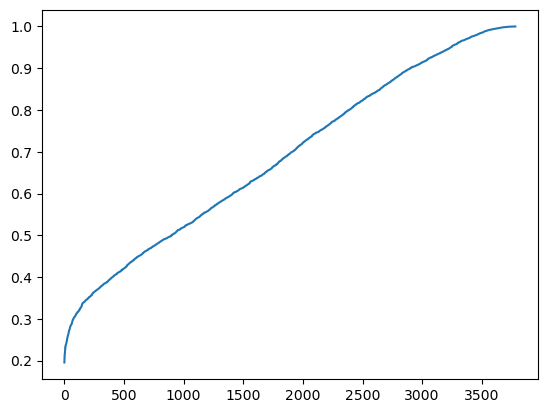

In [96]:
plt.plot(np.sort(cal_scores))

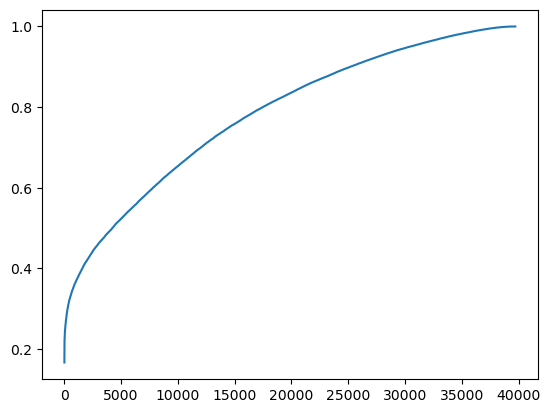